# Code Lab 3. Линейный классификатор Softmax 

Для выполнения этого задания нужно будет дописать код в этом ноутбуке  

В этом упражнении Вам предстоит:

- реализовать векторизованную функцию для вычисления **аналитического градиента** Softmax классификатора
- **оптимизировать** матрицу весов W с помощью стохастического градиентного спуска **SGD**
- **визуализировать** график функции потерь.

In [1]:
import time
import random
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

%matplotlib inline
plt.rcParams['figure.figsize'] = (16.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'

I0000 00:00:1776072902.913390   74369 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776072903.274307   74369 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776072905.287724   74369 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Загрузка датасета CIFAR-10 и предварительная подготовка

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Проверим размер входных и выходных векторов.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print()

/home/user/projects/comp_vision_course/venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000, 1)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000, 1)



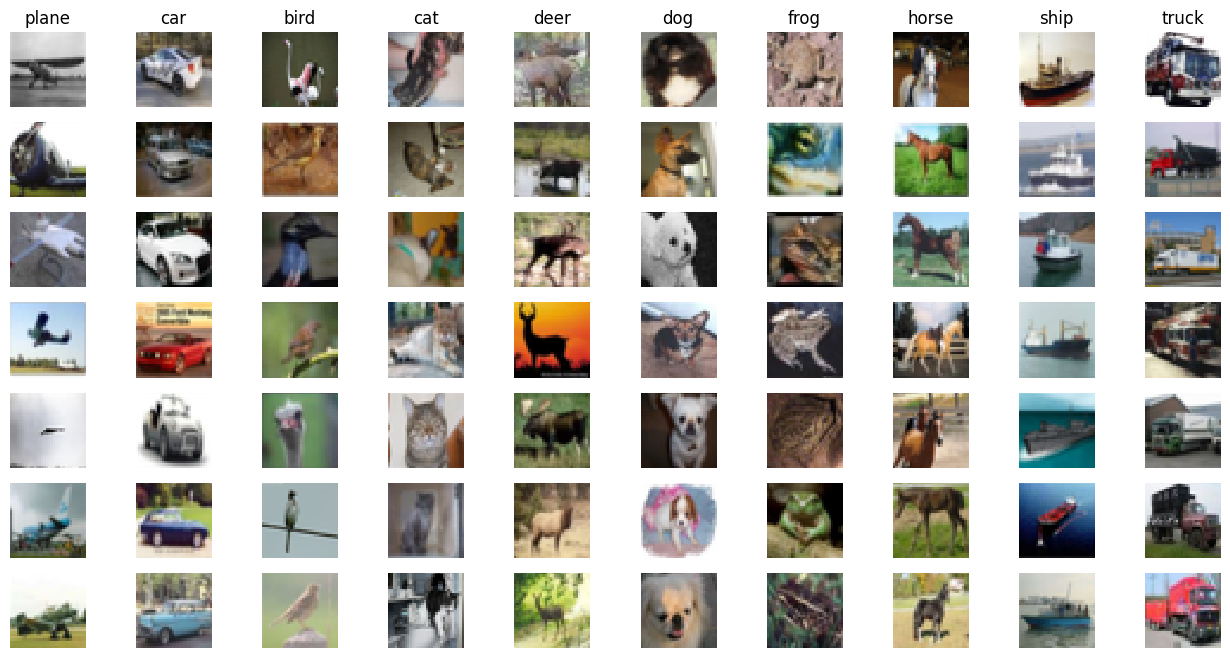

In [3]:
# Перед началом работы полезно посмотреть на данные.
# Отобразим пример из каждого класса.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [4]:
# Для удобства преобразуем двумерные изображения в одномерные вектора fp64
X_train = np.reshape(X_train, (X_train.shape[0], -1)).astype(np.float64)
X_test = np.reshape(X_test, (X_test.shape[0], -1)).astype(np.float64)
y_train = y_train.flatten()
y_test = y_test.flatten()
# Проверим размер полученных данных
print('Training data shape: ', X_train.shape)
print('Test data shape: ', X_test.shape)
print('Training label shape: ', y_train.shape)
print('Test label shape: ', y_test.shape)

Training data shape:  (50000, 3072)
Test data shape:  (10000, 3072)
Training label shape:  (50000,)
Test label shape:  (10000,)


[130.71074 136.05614 132.5538  130.14036 135.44238 131.85358 131.05044
 136.24616 132.58144 131.56886]


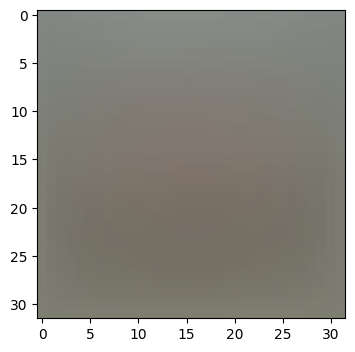

In [5]:
# Нормализуем значения яркости пикселей 
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 

# визуализируем среднюю яркость
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()

In [6]:
# Вычтем средние значения яркости
X_train -= mean_image
X_test -= mean_image

# Добавим к вектору исходных данных фиктивный признак с постоянным значением 1.
# Этот трюк позволит избежать лишних вычислений: x @ W + b  => x' @ W'
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

print(X_train.shape, X_test.shape)

(50000, 3073) (10000, 3073)


## Softmax Classifier


In [7]:
# Небольшая фишка с итерацией по заданному измерению ndarray
p = np.arange(40).reshape(4, 10)
y = 1, 2, 3, 4

print('p = \n', p)
print('y = \n', y)

p = 
 [[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]]
y = 
 (1, 2, 3, 4)


In [8]:
# Возьмем первый элемент из нулевой строки, второй элемент из первой строки и так далее.
p[range(4), y]

array([ 1, 12, 23, 34])

In [9]:
# Реализуйте эффективную векторизованную  функцию вычисления loss и dW

def softmax_loss(W, X, y, reg):
    """
    Функция потерь Softmax, векторизованная версия.
    Входы и выходы такие же, как у softmax_loss_naive.
    """
    # Инициализируем значения loss и градиента нулями.
    loss = 0.0
    dW = np.zeros_like(W)

    #############################################################################
    # TODO: Вычислить softmax loss и его градиент без явных циклов.            #
    # Сохраните значение функции потерь в переменной loss и градиент в dW.     #
    # Будьте внимательны к численной нестабильности при экспонентах. Не забывайте#
    # про регуляризацию!                                                      #
    #############################################################################
    # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
    N = X.shape[0]  # количество объектов
    # Считаем scores
    scores = X.dot(W)
    # Численная стабильность
    scores -= np.max(scores, axis=1, keepdims=True)
    # Softmax вероятности
    exp_scores = np.exp(scores)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    # Loss
    correct_log_probs = -np.log(probs[range(N), y])
    loss = np.sum(correct_log_probs) / N
    # Регуляризация
    loss += reg * np.sum(W * W)
    # Градиент
    dscores = probs.copy()
    dscores[range(N), y] -= 1
    dscores /= N
    dW = X.T.dot(dscores)
    # Градиент регуляризации
    dW += 2 * reg * W
    # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

    return loss, dW


In [10]:
# Инициализируем веса значениями близкими, но не равными нулю
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss(W, X_test, y_test, 0.0)

# Обязательно проверим правильность реализации функции
# Для 10 классов loss должен быть около -log(0.1).
print('loss: %f' % loss)
print('Начальное значение Loss = %f' % (-np.log(0.1)))

loss: 2.351248
Начальное значение Loss = 2.302585


**Вопрос 1**

Объясните, почему мы предположили, что для 10 классов при весах близких к нулю
 softmax loss приблизительно равен -log(0.1)?  
$\color{blue}{\textit Ответ:}$ Когда веса близки к нулю, модель фактически ничего не “знает” и не отдаёт предпочтение ни одному классу. В результате все классы получают примерно одинаковые оценки, а после применения softmax это превращается в равномерное распределение вероятностей.

Если классов 10, то вероятность каждого получается примерно 0.1. Функция потерь в softmax — это отрицательный логарифм вероятности правильного класса. Значит, если модель даёт правильному классу вероятность около 0.1, то и значение loss будет примерно равно -log(0.1).

Проще говоря: в начале обучения модель угадывает на уровне случайного выбора, поэтому и ошибка соответствует «случайному угадыванию» среди 10 классов.


# Стохастический градиентный спуск

In [11]:
class SoftmaxClassifier():
    """Класс линейного классификатора, обучаемого с помощью стохастического градиентного спуска."""
    def __init__(self):
        self.W = None

    def train(self, X, y, learning_rate=1e-3, reg=1e-5, num_iters=100,
              batch_size=32, verbose=True):
        """
        Обучение классификатора с помощью стохастического градиентного спуска.
        Входы:
        - X: numpy массив формы (N, D) с обучающими данными; N примеров, каждое
          размерности D.
        - y: numpy массив формы (N,) с метками; y[i] = c означает, что X[i] имеет
          метку 0 <= c < C для C классов.
        - learning_rate: (float) скорость обучения.
        - reg: (float) сила регуляризации.
        - num_iters: (integer) число шагов оптимизации.
        - batch_size: (integer) число примеров в мини-пакете.
        - verbose: (boolean) если True, выводить прогресс оптимизации.
        Возвращает:
        Список значений функции потерь на каждой итерации обучения.
        """
        num_train, dim = X.shape
        num_classes = np.max(y) + 1 # предполагаем, что y принимает значения 0...K-1
        if self.W is None:
            # лениво инициализируем W
            self.W = 0.001 * np.random.randn(dim, num_classes)

        # Запускаем стохастический градиентный спуск для оптимизации W
        loss_history = []
        for it in range(num_iters):
            # Случайным образом выберем batch_size элементов из обучающего набора и их метки для использования в текущей итерации оптимизации.
            indices = np.random.choice(num_train, batch_size)
            X_batch = X[indices]
            y_batch = y[indices]

            # вычисляем loss и градиент
            loss,  grad = self.loss(X_batch, y_batch, reg)
            loss_history.append(loss)

            # выполняем обновление параметров
            self.W -= learning_rate * grad


            if verbose and it % 100 == 0:
                print('iteration %d / %d: loss %f '  % (it, num_iters, loss))

        return loss_history

    def predict(self, X):
        """
        Использует обученные веса этого линейного классификатора для предсказания
        меток для входных данных.
        Входы:
        - X: numpy массив формы (N, D) с данными; N примеров размерности D.
        Возвращает:
        - y_pred: массив предсказанных меток длины N, каждое значение — целое число
                  с предсказанным классом.
        """

        scores = X.dot(self.W)
        y_pred = np.argmax(scores, axis=1)

        return y_pred

    def loss(self, X_batch, y_batch, reg):
        """
        Вычисляет функцию потерь и её производную.
        Входы:
        - X_batch: numpy массив формы (N, D) с мини-пакетом из N точек; каждая точка размерности D.
        - y_batch: numpy массив формы (N,) с метками для мини-пакета.
        - reg: (float) сила регуляризации.
        Возвращает: кортеж из:
        - loss — одномерное число (float)
        - gradient по отношению к self.W; массив той же формы, что и W
        """
        return softmax_loss(self.W, X_batch, y_batch, reg)
    
    def save_weights(self, path):
        np.save(path, self.W)
    
    def load_weights(self, path):
        self.W = np.load(path)


In [12]:
# Проверьте реализацию на небольшом наборе данных, чтобы убедиться, что она работает и не выдает NaN.

softmax_cls = SoftmaxClassifier()
tic = time.time()
loss_hist = softmax_cls.train(
    X_train[:1000], y_train[:1000], 
    learning_rate=1e-4, reg=1e-3,
    num_iters=1000, verbose=True)

toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1000: loss 5.168616 
iteration 100 / 1000: loss 30.248218 
iteration 200 / 1000: loss 16.584511 
iteration 300 / 1000: loss 7.432166 
iteration 400 / 1000: loss 12.303150 
iteration 500 / 1000: loss 2.702851 
iteration 600 / 1000: loss 21.014360 
iteration 700 / 1000: loss 2.909898 
iteration 800 / 1000: loss 1.485217 
iteration 900 / 1000: loss 0.432103 
That took 0.513402s


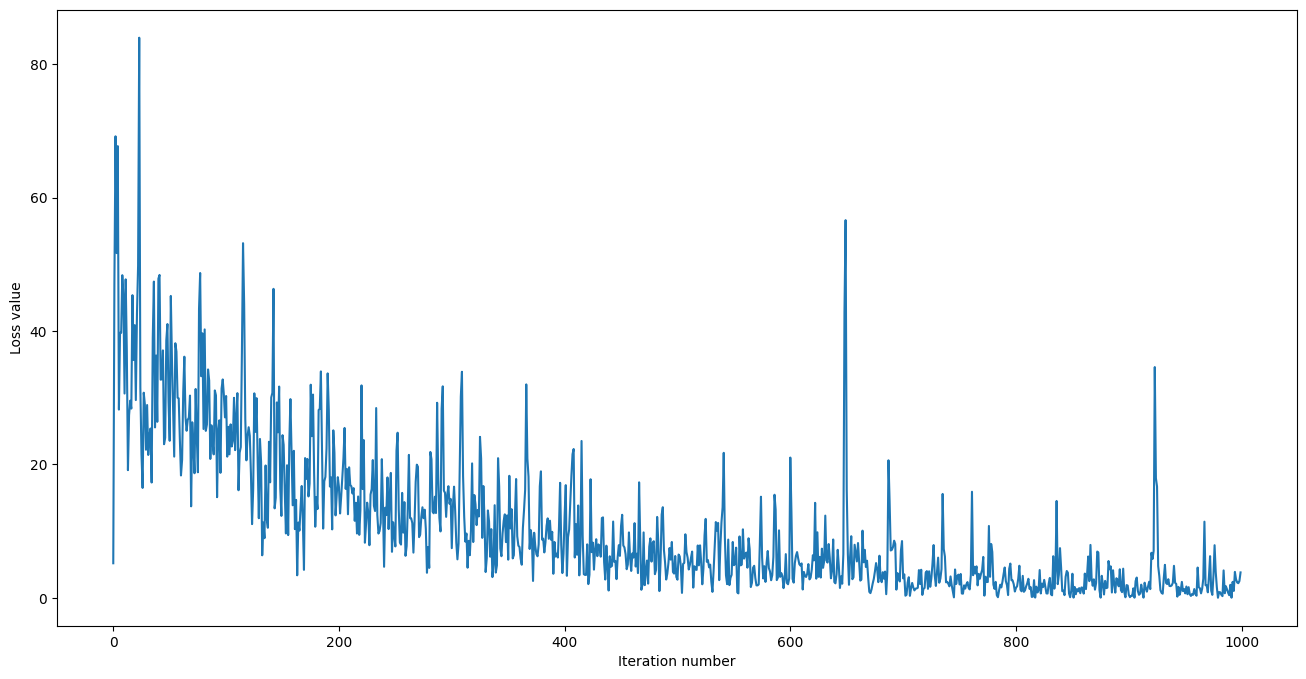

In [13]:
# Построим график зависимости loss от количества итераций
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [14]:
# оцените точность предсказания на выборках train и val
y_train_pred = softmax_cls.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred) ))
y_test_pred = softmax_cls.predict(X_test)
print('validation accuracy: %f' % (np.mean(y_test == y_test_pred) ))

training accuracy: 0.293040
validation accuracy: 0.285600
